# Anatomy of the automated attacks against a single leaked credential

**A threat-intelligence reconstruction from one deliberately-leaked AWS canary token.**

## The experiment

A *canary token* is a fake credential that has no real access to anything. Its
only job is to sound an alarm: the moment someone tries to use it, it emails an
alert capturing the source IP, the API action attempted, and a timestamp. It is
a tripwire for credential theft.

For this project a fake-but-real AWS access key was deliberately published inside
a **public GitHub repository** and left there for roughly one month. The key
granted nothing, but every attempt to authenticate or call an AWS API with it
generated an alert email. Those emails were parsed, the source IPs enriched with
geolocation / ASN / infrastructure type (`ipinfo.io`) and GreyNoise, and each API
call mapped to an attacker-intent phase. The result is **16 real events** — some
from AWS's own automated defenses, most from attacker bots.

## The thesis

Using the owner's own bait, we can reconstruct the *automated attacker playbook*
against a leaked cloud credential and turn raw API calls into a kill-chain:
**validation → reconnaissance → persistence → resource-abuse.** Three facts drive
the story, and each is verified against the data below:

1. **Defense won before the attack began.** AWS auto-quarantined the key first —
   the earliest event is an AWS-internal `AttachUserPolicy` that pinned a
   restrictive policy onto the credential. Every later attacker request hit an
   already-dead key.
2. **Attacker infrastructure escalated** over the month: a camouflaged datacenter
   VPS in Frankfurt → free cloud (Google Cloud, Iowa) → a burst of US
   residential/mobile proxies (AT&T / T-Mobile rotating across cities) →
   Indonesian carriers.
3. **Intent escalated too**: beyond recon there was an IAM `CreateUser` attempt
   (persistence) and an `InvokeModel` attempt (LLMjacking — stealing the key to
   run AI on AWS Bedrock), with named attacker tooling visible in the
   user-agents.

> **A note on the 17 minutes.** The experiment log records that the key was
> published ~17 minutes *before* the AWS quarantine event below. The publication
> timestamp lives in the experiment metadata, not in these CSVs, so this notebook
> treats "17 minutes" as documented context and computes everything else — the
> quarantine time, and the fact that every attacker request came after it —
> directly from the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Colorblind-friendly qualitative palette (Okabe-Ito)
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00",
             "#56B4E9", "#CC79A7", "#F0E442", "#999999"]
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## 2. Load & sanity-check

Both CSVs are read straight from `data/processed/`. The `user_agent` column contains unquoted commas but was written with proper quoting, so `pd.read_csv` handles it — we assert the row count is exactly 16 to be sure nothing shifted.

In [2]:
DATA = Path("..") / "data" / "processed"
alerts = pd.read_csv(DATA / "alerts_enriched.csv")
ip_intel = pd.read_csv(DATA / "ip_intel.csv")

# Parse timestamps
alerts["datetime_utc"] = pd.to_datetime(alerts["datetime_utc"], utc=True)
alerts = alerts.sort_values("seq").reset_index(drop=True)

# Sanity checks
assert len(alerts) == 16, f"expected 16 events, got {len(alerts)}"
attacker_ips = alerts.loc[alerts["alert_type"] == "ip_triggered", "source_ip"]
assert attacker_ips.nunique() == 9, f"expected 9 unique attacker IPs, got {attacker_ips.nunique()}"
assert len(ip_intel) == 9, f"expected 9 rows in ip_intel, got {len(ip_intel)}"

print(f"events              : {len(alerts)}")
print(f"unique attacker IPs : {attacker_ips.nunique()}")
print(f"date range (UTC)    : {alerts['datetime_utc'].min()}  ->  {alerts['datetime_utc'].max()}")
print(f"alert types         : {alerts['alert_type'].value_counts().to_dict()}")

events              : 16
unique attacker IPs : 9
date range (UTC)    : 2026-08-03 06:38:00+00:00  ->  2026-08-27 13:52:00+00:00
alert types         : {'ip_triggered': 13, 'safetynet': 2, 'aws_internal': 1}


In [3]:
alerts[["seq", "datetime_utc", "source_ip", "event_name",
        "infra_type", "country", "intent_phase", "tool_signature"]]

,seq,datetime_utc,source_ip,event_name,infra_type,country,intent_phase,tool_signature
0,1,2026-08-03 06:38:00+00:00,AWS Internal,AttachUserPolicy,NaN,NaN,defense,NaN
1,2,2026-08-04 07:45:00+00:00,NaN,SNS,NaN,NaN,defense,NaN
2,3,2026-08-18 21:30:00+00:00,146.103.40.12,ListAttachedUserPolicies,datacenter VPS,DE,reconnaissance,NaN
3,4,2026-08-20 23:21:00+00:00,34.173.24.24,GetCallerIdentity,cloud,US,validation,NaN
4,5,2026-08-21 00:14:00+00:00,34.173.24.24,GetSendQuota,cloud,US,abuse-prep,DeepAWSAnalyzer/Pro
5,6,2026-08-21 20:36:00+00:00,34.173.24.24,GetRegions,cloud,US,reconnaissance,NaN
6,7,2026-08-24 01:45:00+00:00,NaN,AWSFRAUDGITHUBKEYCLUTCHPROD,NaN,NaN,defense,NaN
7,8,2026-08-25 14:14:00+00:00,99.89.81.59,GetCallerIdentity,residential/mobile,US,validation,NaN
8,9,2026-08-25 14:48:00+00:00,172.56.14.182,DescribeSeverityLevels,residential/mobile,US,reconnaissance,iam_masscek/2.0
9,10,2026-08-25 14:50:00+00:00,172.56.198.175,CreateUser,residential/mobile,US,persistence,iam_masscek/2.0


## 3. Timeline — when the events fired

Sixteen events over ~24 days. The first event is AWS's own defense; everything
after it is an attacker touching a credential that was already inert. Two moments
are worth annotating: the **AWS quarantine** (the very first event) and the
**Aug 25 residential/mobile burst**, when a cluster of US proxy IPs rotated
through in well under an hour.

In [4]:
quarantine = alerts.iloc[0]
q_time = quarantine["datetime_utc"]
print(f"First event (defense): {quarantine['event_name']} at {q_time}")

attackers = alerts[alerts["alert_type"] == "ip_triggered"].copy()
print(f"First attacker request: {attackers['datetime_utc'].min()}")
print(f"All attacker requests after quarantine? "
      f"{(attackers['datetime_utc'] > q_time).all()}")

# The Aug 25 residential/mobile burst
burst = attackers[attackers["datetime_utc"].dt.date == pd.Timestamp('2026-08-25').date()]
burst_recon = burst[burst["infra_type"] == "residential/mobile"]
span_min = (burst_recon["datetime_utc"].max() - burst_recon["datetime_utc"].min()).total_seconds() / 60
print(f"\nAug 25 residential/mobile burst: {len(burst_recon)} events across "
      f"{burst_recon['source_ip'].nunique()} IPs in {span_min:.0f} min")

First event (defense): AttachUserPolicy at 2026-08-03 06:38:00+00:00
First attacker request: 2026-08-18 21:30:00+00:00
All attacker requests after quarantine? True

Aug 25 residential/mobile burst: 5 events across 5 IPs in 167 min


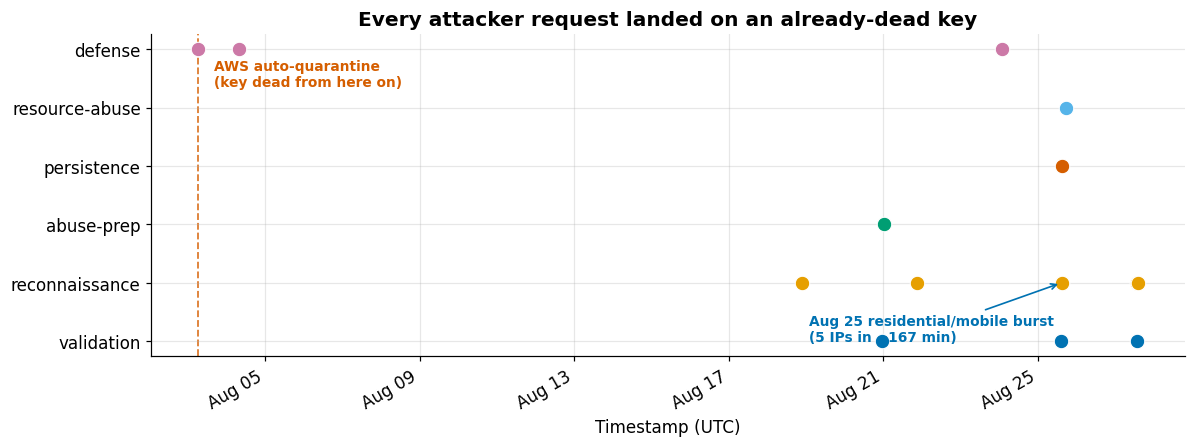

In [5]:
phases = ["validation", "reconnaissance", "abuse-prep",
          "persistence", "resource-abuse", "defense"]
phase_color = {p: OKABE_ITO[i] for i, p in enumerate(phases)}

fig, ax = plt.subplots(figsize=(11, 4.2))
for phase in phases:
    sub = alerts[alerts["intent_phase"] == phase]
    if len(sub):
        ax.scatter(sub["datetime_utc"], [phase] * len(sub),
                   s=90, color=phase_color[phase], edgecolor="white",
                   linewidth=0.7, zorder=3, label=phase)

# Annotate the quarantine
ax.axvline(q_time, color="#D55E00", linestyle="--", linewidth=1.2, alpha=0.8, zorder=1)
ax.annotate("AWS auto-quarantine\n(key dead from here on)",
            xy=(q_time, 4.15), xytext=(10, 8), textcoords="offset points",
            fontsize=9, color="#D55E00", fontweight="bold")

# Annotate the Aug 25 burst
b_time = burst_recon["datetime_utc"].min()
ax.annotate(f"Aug 25 residential/mobile burst\n({len(burst_recon)} IPs in ~{span_min:.0f} min)",
            xy=(b_time, 1.0), xytext=(-165, -38), textcoords="offset points",
            fontsize=9, color="#0072B2", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#0072B2", lw=1.1))

ax.set_yticks(range(len(phases)))
ax.set_yticklabels(phases)
ax.set_title("Every attacker request landed on an already-dead key", fontweight="bold")
ax.set_xlabel("Timestamp (UTC)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. Who — the attacking infrastructure

Nine unique attacker IPs, one event class from AWS itself. The infrastructure
tells an escalation story: it starts on an obvious **datacenter VPS** (Frankfurt),
moves to **free cloud** (Google Cloud, Iowa), then to a wave of **US
residential/mobile proxies** (AT&T and T-Mobile), and finally **Indonesian
carriers** — a drift away from easy-to-block datacenter ranges toward
harder-to-attribute residential space.

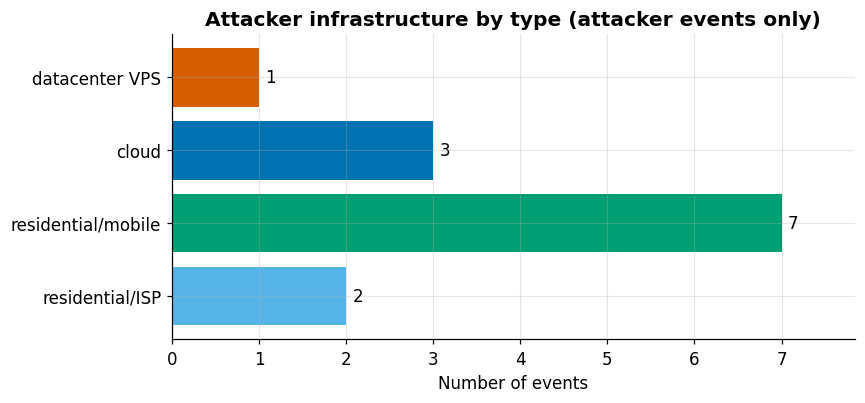

Events per infrastructure type: {'datacenter VPS': 1, 'cloud': 3, 'residential/mobile': 7, 'residential/ISP': 2}


In [6]:
infra_counts = alerts["infra_type"].value_counts()  # NaN (AWS-internal) dropped
order = ["datacenter VPS", "cloud", "residential/mobile", "residential/ISP"]
infra_counts = infra_counts.reindex([o for o in order if o in infra_counts.index])

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(infra_counts.index, infra_counts.values,
               color=[OKABE_ITO[3], OKABE_ITO[0], OKABE_ITO[2], OKABE_ITO[4]])
ax.bar_label(bars, padding=4)
ax.invert_yaxis()
ax.set_xlabel("Number of events")
ax.set_title("Attacker infrastructure by type (attacker events only)", fontweight="bold")
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

print("Events per infrastructure type:", infra_counts.to_dict())

In [7]:
# Geographic + chronological escalation, straight from the enriched rows
geo = (attackers[["seq", "datetime_utc", "source_ip", "infra_type",
                  "city", "country", "org"]]
       .assign(date=lambda d: d["datetime_utc"].dt.strftime("%b %d %H:%M")))
print("Countries touched (attacker events):",
      attackers["country"].value_counts().to_dict())
print("Distinct orgs/networks:", attackers["org"].nunique())
geo[["seq", "date", "source_ip", "org", "city", "country", "infra_type"]]

Countries touched (attacker events): {'US': 8, 'ID': 4, 'DE': 1}
Distinct orgs/networks: 6


,seq,date,source_ip,org,city,country,infra_type
2,3,Aug 18 21:30,146.103.40.12,Regxa Company for Information Technology Ltd,Frankfurt am Main,DE,datacenter VPS
3,4,Aug 20 23:21,34.173.24.24,Google LLC,Council Bluffs,US,cloud
4,5,Aug 21 00:14,34.173.24.24,Google LLC,Council Bluffs,US,cloud
5,6,Aug 21 20:36,34.173.24.24,Google LLC,Council Bluffs,US,cloud
7,8,Aug 25 14:14,99.89.81.59,"AT&T Enterprises, LLC",Lansing,US,residential/mobile
8,9,Aug 25 14:48,172.56.14.182,"T-Mobile USA, Inc.",Sacramento,US,residential/mobile
9,10,Aug 25 14:50,172.56.198.175,"T-Mobile USA, Inc.",Boston,US,residential/mobile
10,11,Aug 25 14:51,99.63.197.17,"AT&T Enterprises, LLC",Reston,US,residential/mobile
11,12,Aug 25 17:01,172.58.243.229,"T-Mobile USA, Inc.",Baltimore,US,residential/mobile
12,13,Aug 27 13:20,182.4.101.162,PT. Telekomunikasi Selular,Yogyakarta,ID,residential/mobile


## 5. What — the intent kill-chain

Each AWS API call is mapped to an attacker-lifecycle phase. Counting the phases
shows recon dominating (the bots spend most effort enumerating the account), but
the tail is where the story is: a single **`CreateUser`** (persistence) and a
single **`InvokeModel`** (resource-abuse) attempt.

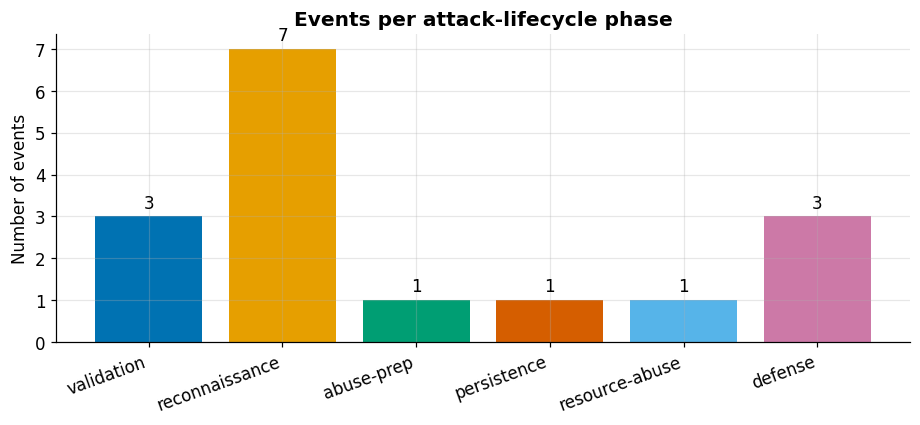

{'validation': 3, 'reconnaissance': 7, 'abuse-prep': 1, 'persistence': 1, 'resource-abuse': 1, 'defense': 3}


In [8]:
phase_counts = alerts["intent_phase"].value_counts().reindex(phases).dropna()

fig, ax = plt.subplots(figsize=(8.5, 4))
bars = ax.bar(phase_counts.index, phase_counts.values,
              color=[phase_color[p] for p in phase_counts.index])
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of events")
ax.set_title("Events per attack-lifecycle phase", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(phase_counts.to_dict())

In [9]:
# The reconstructed playbook: which API calls appeared in each phase
playbook = (alerts[alerts["alert_type"] == "ip_triggered"]
            .groupby("intent_phase")["event_name"]
            .apply(lambda s: ", ".join(sorted(s.unique())))
            .reindex([p for p in phases if p != "defense"])
            .dropna())
for phase in playbook.index:
    print(f"{phase:>15} :  {playbook[phase]}")

     validation :  GetCallerIdentity
 reconnaissance :  DescribeSeverityLevels, GetAccount, GetRegions, GetServiceQuota, GetUser, ListAttachedUserPolicies, ListRoles
     abuse-prep :  GetSendQuota
    persistence :  CreateUser
 resource-abuse :  InvokeModel


### The two standout findings

- **Persistence — `CreateUser` (seq 10).** From a T-Mobile residential/mobile IP
  in Boston, the bot tried to *create a brand-new IAM user* — the classic move to
  keep a foothold even after the leaked key is revoked. On a live account this is
  how a single leaked key becomes durable account compromise.
- **Resource-abuse — `InvokeModel` (seq 12), i.e. LLMjacking.** From a T-Mobile
  IP in Baltimore, the bot tried to run models on **AWS Bedrock** at the victim's
  expense — hijacking the account's AI inference. This is one of the newer
  monetization patterns for stolen cloud credentials.

Both are shown below verbatim from the data.

In [10]:
standouts = alerts[alerts["event_name"].isin(["CreateUser", "InvokeModel"])]
standouts[["seq", "datetime_utc", "source_ip", "event_name", "org",
           "city", "country", "intent_phase", "intent_description"]]

,seq,datetime_utc,source_ip,event_name,org,city,country,intent_phase,intent_description
9,10,2026-08-25 14:50:00+00:00,172.56.198.175,CreateUser,"T-Mobile USA, Inc.",Boston,US,persistence,Attempts to create a new IAM user to retain ac...
11,12,2026-08-25 17:01:00+00:00,172.58.243.229,InvokeModel,"T-Mobile USA, Inc.",Baltimore,US,resource-abuse,Attempts to run AI models on AWS Bedrock at th...


## 6. Tooling fingerprints

Two requests carry a **named tool signature** appended to the boto3 user-agent —
a fingerprint the operators did not bother to strip. Alongside them, the parsed
OS / Python / boto3 spread shows the requests did not all come from one machine.

In [11]:
tools = alerts.loc[alerts["tool_signature"].notna(),
                   ["seq", "source_ip", "event_name", "tool_signature", "intent_phase"]]
print("Named tool signatures:")
print(alerts["tool_signature"].value_counts().to_dict())
tools

Named tool signatures:
{'iam_masscek/2.0': 3, 'DeepAWSAnalyzer/Pro': 1}


,seq,source_ip,event_name,tool_signature,intent_phase
4,5,34.173.24.24,GetSendQuota,DeepAWSAnalyzer/Pro,abuse-prep
8,9,172.56.14.182,DescribeSeverityLevels,iam_masscek/2.0,reconnaissance
9,10,172.56.198.175,CreateUser,iam_masscek/2.0,persistence
10,11,99.63.197.17,GetAccount,iam_masscek/2.0,reconnaissance


In [12]:
fingerprint = (alerts[alerts["alert_type"] == "ip_triggered"]
               [["ua_os", "ua_python", "ua_boto3", "ua_retry_mode"]])
for col in fingerprint.columns:
    print(f"{col:>15} : {fingerprint[col].value_counts().to_dict()}")

          ua_os : {'windows#10': 5, 'windows#2022Server': 4, 'linux#5.15.0-46-generic': 4}
      ua_python : {'3.11.2': 6, '3.10.12': 4, '3.14.2': 3}
       ua_boto3 : {'1.43.74': 4, '1.43.81': 4, '1.43.65': 3, '1.43.68': 1, '1.38.31': 1}
  ua_retry_mode : {'standard': 6, 'legacy': 4, 'adaptive': 3}


## 7. The punchline — defense speed vs attack timing

The whole month of attacker activity is a race that was already lost before it
started. AWS's quarantine is the *first* event in the dataset; every single
attacker request — validation, recon, the persistence attempt, the LLMjacking
attempt — arrives days later, against a credential that has been inert since
minute 17.

In [13]:
n_attacker = len(attackers)
n_after = int((attackers["datetime_utc"] > q_time).all()) and n_attacker
gap_first = attackers["datetime_utc"].min() - q_time
gap_last = attackers["datetime_utc"].max() - q_time

print(f"AWS quarantine event    : {quarantine['event_name']} @ {q_time}")
print(f"Attacker requests total : {n_attacker}")
print(f"...landing AFTER quarantine: {n_after} / {n_attacker} "
      f"({100 * n_after / n_attacker:.0f}%)")
print(f"First attacker hit came {gap_first.days} days "
      f"{gap_first.components.hours}h after the key was already dead")
print(f"Last attacker hit came  {gap_last.days} days after quarantine")
print("\nDocumented context: the key was published ~17 minutes before that "
      "quarantine event (experiment metadata).")

AWS quarantine event    : AttachUserPolicy @ 2026-08-03 06:38:00+00:00
Attacker requests total : 13
...landing AFTER quarantine: 13 / 13 (100%)
First attacker hit came 15 days 14h after the key was already dead
Last attacker hit came  24 days after quarantine

Documented context: the key was published ~17 minutes before that quarantine event (experiment metadata).


## 8. Scope & limitations

This is deliberately **descriptive threat-intelligence storytelling, not
statistical modelling or ML.**

- **Small dataset.** Sixteen events (13 attacker requests, 9 unique IPs) is
  enough to *describe* behavior, not to make statistical or predictive claims.
  Treat every count here as descriptive of this one credential, this one month.
- **No population inference.** Nothing here generalizes to "all leaked keys." A
  single canary in a single repo is a case study, not a sample.
- **No attribution of people.** Enrichment identifies *infrastructure* — IPs,
  ASNs, geography, tool strings — not the humans behind it. The residential/mobile
  and cloud origins are very likely proxies or compromised hosts, not the
  operators' own machines. Attributing individuals is out of scope and would
  require legal process.
- **Absence of GreyNoise signal.** All nine IPs returned 404 from GreyNoise
  community (not observed scanning). That is a genuine absence of signal, not a
  clean bill of health.
- **One boto3-shaped lens.** The canary only sees requests that reached AWS with
  this key. Anything that scraped the repo without ever calling AWS is invisible
  here.

What the data *does* support is the narrative spine: a leaked cloud credential
draws automated traffic within days, that traffic escalates in both
infrastructure and intent, and — in this case — a fast automated defense made all
of it moot.